In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
from utils import bfs, dfs, ucs, haversine_km, load_openflights, plot_route_paths, route_is_valid
ROOT = Path.cwd().parent # the course folder
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab01"
RESULTS.mkdir(parents=True, exist_ok=True)

In [4]:
airports, routes, coords, graph, stats = load_openflights(DATA / "lab01-03_airports.csv", DATA / "lab01-03_routes.csv")
queries = pd.read_csv("utils/search_queries.csv").head(3)
display(pd.Series(stats, name="count").to_frame())
display(queries)

,count
airport_rows,10668
valid_airports,6464
route_rows,67663
unique_valid_routes,37337
removed_route_rows,30326


,query_id,start,goal
0,Q1,KUL,KEF
1,Q2,SIN,EZE
2,Q3,NRT,CPT


In [5]:
sample = pd.DataFrame(graph["KUL"][:5], columns=["destination"
,
"distance_km"])
display(sample.round(1))
direct_km = haversine_km(coords["KUL"]["latitude"], coords["KUL"]["longitude"],
coords["KEF"]["latitude"], coords["KEF"]["longitude"])
print(f"KUL has {len(graph['KUL'])} outgoing routes")
print(f"Great-circle distance KUL -> KEF: {direct_km:,.0f} km (no direct route exists)")

,destination,distance_km
0,ADL,5681.8
1,AKL,8703.4
2,ALA,5130.5
3,AMD,3861.2
4,AMS,10236.7


KUL has 112 outgoing routes
Great-circle distance KUL -> KEF: 11,316 km (no direct route exists)


In [7]:
rows = []
for query in queries.itertuples():
    for name, algorithm in [("BFS", bfs), ("DFS", dfs), ("UCS", ucs)]:
        result = algorithm(graph, query.start, query.goal)
        rows.append({"query_id": query.query_id, "start": query.start, "goal": query.goal,
            "algorithm": name, **result.as_dict(), "path": " -> ".join(result.path)})

metrics = pd.DataFrame(rows).drop(columns="found")
metrics.to_csv(RESULTS / "metrics.csv", index=False)
display(metrics.drop(columns=["start","goal","path"]).round(2))

,query_id,algorithm,hops,path_cost_km,expanded,max_frontier,runtime_ms
0,Q1,BFS,2,12274.32,284,1679,6.77
1,Q1,DFS,23,41767.82,2112,859,4.45
2,Q1,UCS,4,11461.35,1851,616,7.03
3,Q2,BFS,2,21976.11,233,1629,3.28
4,Q2,DFS,39,65213.84,904,858,3.70
5,Q2,UCS,3,17817.36,3002,620,9.46
6,Q3,BFS,2,19005.89,173,1727,3.22
7,Q3,DFS,64,91541.43,1414,785,3.81
8,Q3,UCS,3,14813.32,3042,1018,9.40


In [8]:
edge_km = {airport: dict(neighbours) for airport, neighbours in graph.items()}

for row in metrics.itertuples():
    path = row.path.split(" -> ")
    assert route_is_valid(path, graph), f"{row.algorithm} {row.query_id}: a leg is not a real route"
    recomputed = sum(edge_km[a][b] for a, b in zip(path, path[1:]))
    assert np.isclose(recomputed, row.path_cost_km), f"{row.algorithm} {row.query_id}: cost mismatch"
    
print(f"Verified {len(metrics)} paths: every leg exists and every cost matches its edge sum")

Verified 9 paths: every leg exists and every cost matches its edge sum


In [9]:
display(metrics.pivot(index="query_id", columns="algorithm", values=["hops","path_cost_km"]).round(0))

reversed_graph = {airport: neighbours[::-1] for airport, neighbours in graph.items()}
for query in queries.itertuples():
    original = dfs(graph, query.start, query.goal).hops
    reordered = dfs(reversed_graph, query.start, query.goal).hops
    print(f"{query.query_id} DFS: {original} hops with the original order, {reordered} with the reversed order")

hops            path_cost_km                  
algorithm  BFS   DFS  UCS          BFS      DFS      UCS
query_id                                                
Q1         2.0  23.0  4.0      12274.0  41768.0  11461.0
Q2         2.0  39.0  3.0      21976.0  65214.0  17817.0
Q3         2.0  64.0  3.0      19006.0  91541.0  14813.0

Q1 DFS: 23 hops with the original order, 8 with the reversed order
Q2 DFS: 39 hops with the original order, 41 with the reversed order
Q3 DFS: 64 hops with the original order, 39 with the reversed order


Saved: ['metrics.csv', 'route_comparison.png']


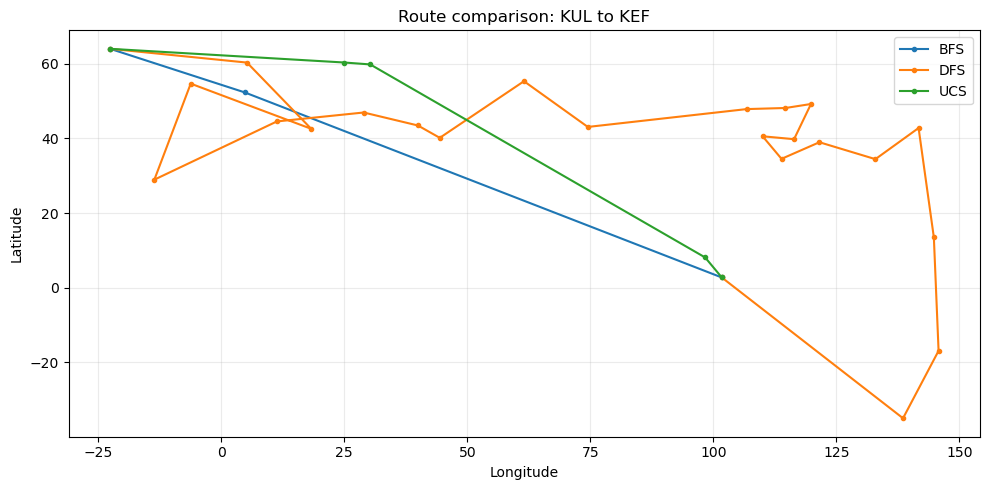

In [10]:
q1 = metrics[metrics.query_id == "Q1"]
paths = {row.algorithm: row.path.split(" -> ") for row in q1.itertuples()}
figure, _ = plot_route_paths(paths, coords, title="Route comparison: KUL to KEF")
figure.savefig(RESULTS / "route_comparison.png", dpi=160, bbox_inches="tight")
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))